In [2]:
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


SEED = 42
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))



Device: cuda
GPU: Tesla T4


## Configuration



In [3]:
DATA_ROOT = Path("/content/data")
CUB_ROOT = DATA_ROOT / "CUB_200_2011"
ARCHIVE_PATH = DATA_ROOT / "CUB_200_2011.tgz"
DATA_URL = "https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1"

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
EPOCHS = 15
FREEZE_BACKBONE_EPOCHS = 1
LR_HEAD = 3e-4
LR_FINE_TUNE = 1e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
USE_BBOX_CROP = True
SMOKE_TEST = False

CHECKPOINT_DIR = Path("/content/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEST_CHECKPOINT = CHECKPOINT_DIR / "best_cub200_efficientnet_b0.pt"



## Download and Extract CUB-200-2011




In [4]:
DATA_ROOT.mkdir(parents=True, exist_ok=True)

if not CUB_ROOT.exists():
    if not ARCHIVE_PATH.exists():
        print("Downloading CUB-200-2011...")
        !wget -q --show-progress -O "{ARCHIVE_PATH}" "{DATA_URL}"
    print("Extracting archive...")
    !tar -xzf "{ARCHIVE_PATH}" -C "{DATA_ROOT}"
else:
    print("Dataset already extracted.")

assert CUB_ROOT.exists(), f"Could not find extracted dataset at {CUB_ROOT}"
print("Dataset root:", CUB_ROOT)



/content/data/CUB_2 100%[===================>]   1.07G  13.2MB/s    in 99s     
Extracting archive...
Dataset root: /content/data/CUB_200_2011


## Read Metadata




In [5]:
def read_table(path, names):
    return pd.read_csv(path, sep=r"\s+", header=None, names=names)


images_df = read_table(CUB_ROOT / "images.txt", ["image_id", "file_name"])
labels_df = read_table(CUB_ROOT / "image_class_labels.txt", ["image_id", "class_id"])
split_df = read_table(CUB_ROOT / "train_test_split.txt", ["image_id", "is_train"])
bbox_df = read_table(CUB_ROOT / "bounding_boxes.txt", ["image_id", "x", "y", "w", "h"])
classes_df = read_table(CUB_ROOT / "classes.txt", ["class_id", "class_name"])

metadata = (
    images_df
    .merge(labels_df, on="image_id")
    .merge(split_df, on="image_id")
    .merge(bbox_df, on="image_id")
)
metadata["label"] = metadata["class_id"] - 1
metadata["path"] = metadata["file_name"].apply(lambda name: CUB_ROOT / "images" / name)

class_names = (
    classes_df.sort_values("class_id")["class_name"]
    .str.replace(r"^\d+\.", "", regex=True)
    .str.replace("_", " ", regex=False)
    .tolist()
)
NUM_CLASSES = len(class_names)

train_df = metadata[metadata["is_train"] == 1].reset_index(drop=True)
test_df = metadata[metadata["is_train"] == 0].reset_index(drop=True)

if SMOKE_TEST:
    train_df = train_df.sample(800, random_state=SEED).reset_index(drop=True)
    test_df = test_df.sample(400, random_state=SEED).reset_index(drop=True)

print(f"Classes: {NUM_CLASSES}")
print(f"Train images: {len(train_df):,}")
print(f"Test images: {len(test_df):,}")
train_df.head()



Classes: 200
Train images: 5,994
Test images: 5,794


,image_id,file_name,class_id,is_train,x,y,w,h,label,path
0,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,139.0,30.0,153.0,264.0,0,/content/data/CUB_200_2011/images/001.Black_fo...
1,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,112.0,90.0,255.0,242.0,0,/content/data/CUB_200_2011/images/001.Black_fo...
2,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,70.0,50.0,134.0,303.0,0,/content/data/CUB_200_2011/images/001.Black_fo...
3,7,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,7.0,75.0,420.0,262.0,0,/content/data/CUB_200_2011/images/001.Black_fo...
4,8,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,78.0,86.0,333.0,158.0,0,/content/data/CUB_200_2011/images/001.Black_fo...


## Dataset and DataLoaders



In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.55, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.15)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def crop_with_bbox(image, row, padding=0.10):
    width, height = image.size
    x, y, w, h = float(row["x"]), float(row["y"]), float(row["w"]), float(row["h"])
    pad_x = padding * w
    pad_y = padding * h
    left = max(0, int(x - pad_x))
    top = max(0, int(y - pad_y))
    right = min(width, int(x + w + pad_x))
    bottom = min(height, int(y + h + pad_y))
    return image.crop((left, top, right, bottom))


class CUBDataset(Dataset):
    def __init__(self, frame, transform=None, use_bbox_crop=True):
        self.samples = frame.to_dict("records")
        self.transform = transform
        self.use_bbox_crop = use_bbox_crop

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        row = self.samples[index]
        image = Image.open(row["path"]).convert("RGB")

        if self.use_bbox_crop:
            image = crop_with_bbox(image, row)

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["label"])
        return image, label


train_ds = CUBDataset(train_df, train_transform, USE_BBOX_CROP)
test_ds = CUBDataset(test_df, eval_transform, USE_BBOX_CROP)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    persistent_workers=NUM_WORKERS > 0,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    persistent_workers=NUM_WORKERS > 0,
)

print("Batches:", len(train_loader), "train,", len(test_loader), "test")



Batches: 188 train, 182 test


## Visualize Training Samples



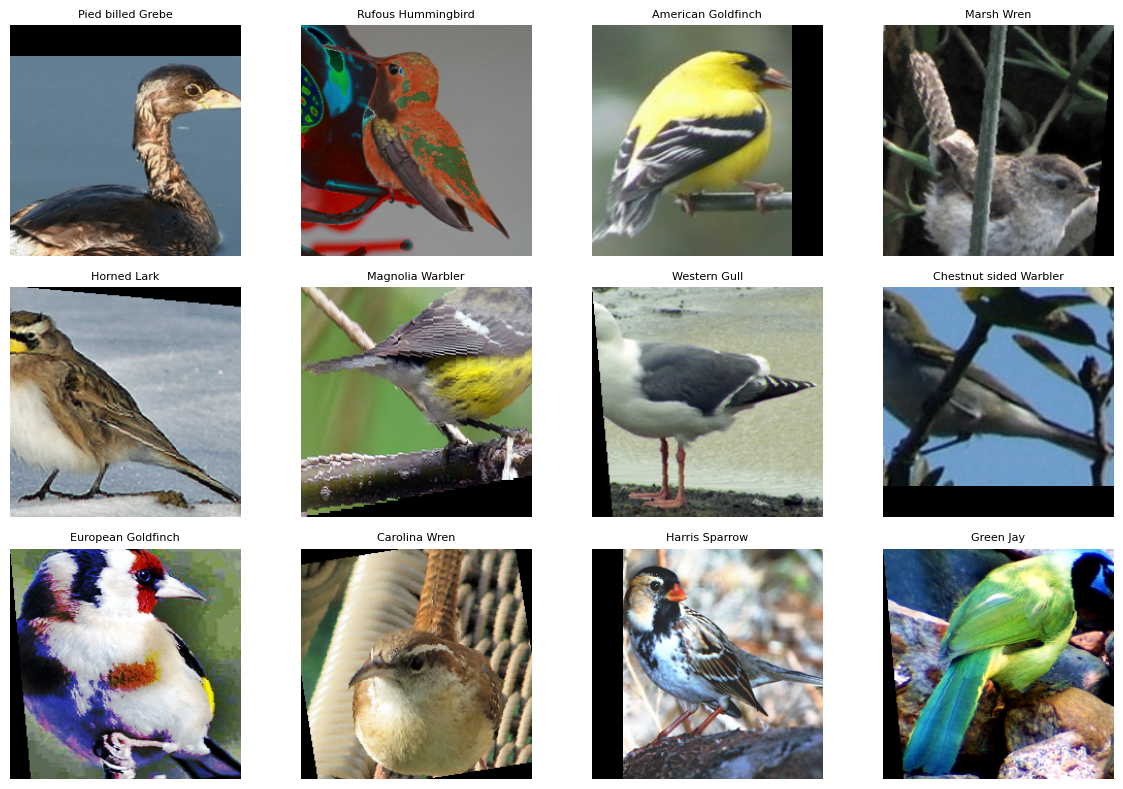

In [7]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 8))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title(class_names[int(labels[i].item())], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()



## AI Model



In [8]:
def build_model(num_classes):
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def set_backbone_trainable(model, trainable):
    for parameter in model.features.parameters():
        parameter.requires_grad = trainable


def make_optimizer(model, lr):
    parameters = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(parameters, lr=lr, weight_decay=WEIGHT_DECAY)


model = build_model(NUM_CLASSES).to(DEVICE)
set_backbone_trainable(model, False)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = make_optimizer(model, LR_HEAD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=max(1, FREEZE_BACKBONE_EPOCHS)
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")



Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 86.2MB/s]


Total parameters: 4,263,748
Trainable parameters: 256,200


## Training and Evaluation Helpers



In [9]:
def topk_accuracy(logits, targets, topk=(1, 5)):
    max_k = max(topk)
    _, pred = logits.topk(max_k, dim=1)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1).expand_as(pred))

    results = []
    batch_size = targets.size(0)
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum().item()
        results.append(100.0 * correct_k / batch_size)
    return results


def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    running_loss = 0.0
    running_top1 = 0.0
    running_top5 = 0.0
    seen = 0

    progress = tqdm(loader, desc="train", leave=False)
    for images, targets in progress:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        batch_size = targets.size(0)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=DEVICE.type == "cuda"):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        top1, top5 = topk_accuracy(logits.detach(), targets)
        running_loss += loss.item() * batch_size
        running_top1 += top1 * batch_size
        running_top5 += top5 * batch_size
        seen += batch_size

        progress.set_postfix(
            loss=running_loss / seen,
            top1=running_top1 / seen,
            top5=running_top5 / seen,
        )

    return {
        "loss": running_loss / seen,
        "top1": running_top1 / seen,
        "top5": running_top5 / seen,
    }


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    running_top1 = 0.0
    running_top5 = 0.0
    seen = 0

    for images, targets in tqdm(loader, desc="eval", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        batch_size = targets.size(0)

        with torch.cuda.amp.autocast(enabled=DEVICE.type == "cuda"):
            logits = model(images)
            loss = criterion(logits, targets)

        top1, top5 = topk_accuracy(logits, targets)
        running_loss += loss.item() * batch_size
        running_top1 += top1 * batch_size
        running_top5 += top5 * batch_size
        seen += batch_size

    return {
        "loss": running_loss / seen,
        "top1": running_top1 / seen,
        "top5": running_top5 / seen,
    }



## Train



In [10]:
history = []
best_top1 = 0.0
scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == "cuda")

for epoch in range(1, EPOCHS + 1):
    if epoch == FREEZE_BACKBONE_EPOCHS + 1:
        print("Unfreezing EfficientNet backbone for fine-tuning.")
        set_backbone_trainable(model, True)
        optimizer = make_optimizer(model, LR_FINE_TUNE)
        remaining_epochs = max(1, EPOCHS - FREEZE_BACKBONE_EPOCHS)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=remaining_epochs
        )

    start_time = time.time()
    train_stats = train_one_epoch(model, train_loader, optimizer, scaler)
    test_stats = evaluate(model, test_loader)
    scheduler.step()

    row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        "train_loss": train_stats["loss"],
        "train_top1": train_stats["top1"],
        "train_top5": train_stats["top5"],
        "test_loss": test_stats["loss"],
        "test_top1": test_stats["top1"],
        "test_top5": test_stats["top5"],
        "minutes": (time.time() - start_time) / 60,
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {row['train_loss']:.4f}, top1 {row['train_top1']:.2f}, top5 {row['train_top5']:.2f} | "
        f"test loss {row['test_loss']:.4f}, top1 {row['test_top1']:.2f}, top5 {row['test_top5']:.2f} | "
        f"{row['minutes']:.1f} min"
    )

    if test_stats["top1"] > best_top1:
        best_top1 = test_stats["top1"]
        torch.save(
            {
                "model_state": model.state_dict(),
                "class_names": class_names,
                "config": {
                    "image_size": IMAGE_SIZE,
                    "use_bbox_crop": USE_BBOX_CROP,
                    "model": "efficientnet_b0",
                },
                "best_top1": best_top1,
                "epoch": epoch,
            },
            BEST_CHECKPOINT,
        )
        print(f"Saved new best checkpoint: {BEST_CHECKPOINT} ({best_top1:.2f}% top-1)")

print(f"Best top-1 accuracy: {best_top1:.2f}%")



train:   0%|          | 0/188 [00:00<?, ?it/s]

eval:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch 01/15 | train loss 4.9883, top1 10.93, top5 26.48 | test loss 4.5137, top1 36.07, top5 67.43 | 1.6 min
Saved new best checkpoint: /content/checkpoints/best_cub200_efficientnet_b0.pt (36.07% top-1)
Unfreezing EfficientNet backbone for fine-tuning.


train:   0%|          | 0/188 [00:00<?, ?it/s]

eval:   0%|          | 0/182 [00:00<?, ?it/s]

...

eval:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch 14/15 | train loss 1.3869, top1 90.69, top5 98.93 | test loss 1.6550, top1 78.37, top5 95.41 | 1.3 min


train:   0%|          | 0/188 [00:00<?, ?it/s]

eval:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch 15/15 | train loss 1.3774, top1 91.01, top5 99.02 | test loss 1.6519, top1 78.48, top5 95.41 | 1.3 min
Best top-1 accuracy: 78.58%


## Plot Training Curves



,epoch,lr,train_loss,train_top1,train_top5,test_loss,test_top1,test_top5,minutes
0,1,0.000000,4.988322,10.927594,26.476476,4.513708,36.071798,67.431826,1.570086
1,2,0.000099,3.710478,40.907574,74.074074,2.944603,55.505696,85.070763,3.000672
2,3,0.000095,2.759921,59.042376,86.986987,2.367895,65.567829,90.662755,1.262834
3,4,0.000089,2.276532,69.002336,92.392392,2.085714,69.502934,92.854677,1.245637
4,5,0.000081,1.987438,76.126126,94.544545,1.929432,72.954781,93.700380,1.270341
5,6,0.000072,1.814577,78.895562,96.296296,1.823020,75.733517,94.822230,1.269151
6,7,0.000061,1.677793,82.766099,97.163830,1.757850,76.113221,95.012081,1.256564
7,8,0.000050,1.586174,84.718051,97.580914,1.727493,76.889886,95.046600,1.271615
8,9,0.000039,1.513462,87.337337,98.114781,1.699740,77.493959,95.270970,1.252638
9,10,0.000028,1.460252,88.555222,98.465132,1.681261,78.115292,95.391785,1.281725


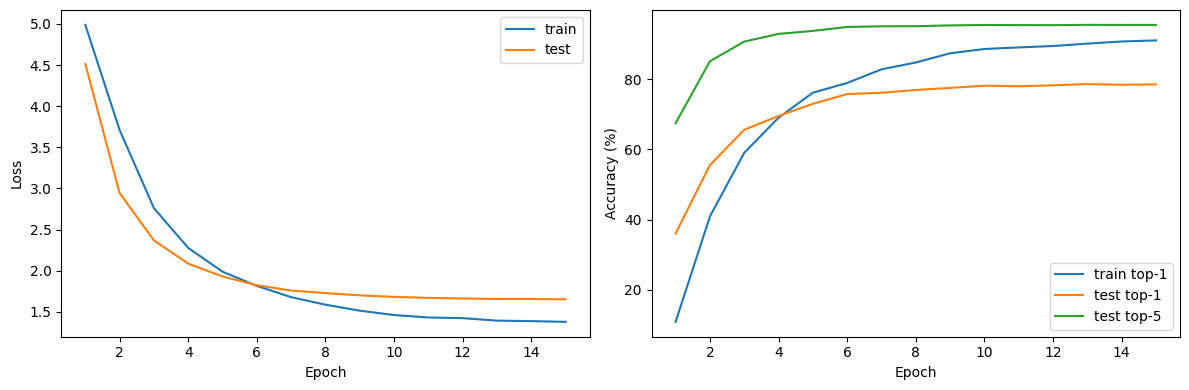

In [11]:
history_df = pd.DataFrame(history)
display(history_df)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["test_loss"], label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["epoch"], history_df["train_top1"], label="train top-1")
plt.plot(history_df["epoch"], history_df["test_top1"], label="test top-1")
plt.plot(history_df["epoch"], history_df["test_top5"], label="test top-5")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()



## Evaluation



In [12]:
checkpoint = torch.load(BEST_CHECKPOINT, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

all_targets = []
all_preds = []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="predict"):
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.numpy().tolist())

cm = confusion_matrix(all_targets, all_preds, labels=list(range(NUM_CLASSES)))
mistakes = []
for true_idx in range(NUM_CLASSES):
    for pred_idx in range(NUM_CLASSES):
        count = cm[true_idx, pred_idx]
        if true_idx != pred_idx and count > 0:
            mistakes.append((count, class_names[true_idx], class_names[pred_idx]))

mistakes = sorted(mistakes, reverse=True)[:15]
print("Top confused class pairs:")
for count, true_name, pred_name in mistakes:
    print(f"{count:3d} images | true: {true_name:30s} predicted: {pred_name}")



predict:   0%|          | 0/182 [00:00<?, ?it/s]

Top confused class pairs:
 14 images | true: Forsters Tern                  predicted: Common Tern
 14 images | true: California Gull                predicted: Western Gull
 11 images | true: Long tailed Jaeger             predicted: Pomarine Jaeger
 10 images | true: Chuck will Widow               predicted: Whip poor Will
  9 images | true: Herring Gull                   predicted: Glaucous winged Gull
  9 images | true: Elegant Tern                   predicted: Caspian Tern
  9 images | true: Common Tern                    predicted: Artic Tern
  8 images | true: Western Wood Pewee             predicted: Sayornis
  8 images | true: Western Wood Pewee             predicted: Olive sided Flycatcher
  8 images | true: American Crow                  predicted: Common Raven
  7 images | true: Pine Warbler                   predicted: Yellow throated Vireo
  7 images | true: House Wren                     predicted: Winter Wren
  7 images | true: Great Grey Shrike              predicted: L

## Predict on a Test Image



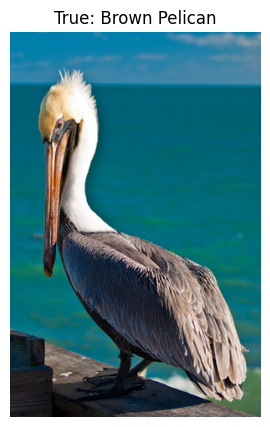

Top predictions:
90.37%  Brown Pelican
 4.74%  White Pelican
 0.25%  Brandt Cormorant
 0.20%  Western Grebe
 0.19%  Frigatebird


In [13]:
def load_and_prepare_image(row, use_bbox_crop=True):
    image = Image.open(row["path"]).convert("RGB")
    if use_bbox_crop:
        image = crop_with_bbox(image, row)
    return image


@torch.no_grad()
def predict_pil_image(image, topk=5):
    model.eval()
    tensor = eval_transform(image).unsqueeze(0).to(DEVICE)
    logits = model(tensor)
    probabilities = torch.softmax(logits, dim=1)[0]
    scores, indices = probabilities.topk(topk)
    return [
        (class_names[int(idx.item())], float(score.item()))
        for score, idx in zip(scores.cpu(), indices.cpu())
    ]


row = test_df.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
image = load_and_prepare_image(row, USE_BBOX_CROP)
predictions = predict_pil_image(image, topk=5)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(f"True: {class_names[int(row['label'])]}")
plt.show()

print("Top predictions:")
for name, score in predictions:
    print(f"{score:6.2%}  {name}")



## Upload Image


In [ ]:
from io import BytesIO

try:
    from google.colab import files
except ImportError as exc:
    raise RuntimeError("This upload cell is intended to run inside Google Colab.") from exc


def ensure_best_model_loaded():
    if BEST_CHECKPOINT.exists():
        checkpoint = torch.load(BEST_CHECKPOINT, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state"])
        print(
            f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')} "
            f"with best top-1 accuracy {checkpoint.get('best_top1', 0):.2f}%"
        )
    else:
        print("No checkpoint found yet. Using the model currently in memory.")
    model.eval()


@torch.no_grad()
def predict_uploaded_image(image, topk=5):
    tensor = eval_transform(image).unsqueeze(0).to(DEVICE)
    logits = model(tensor)
    probabilities = torch.softmax(logits, dim=1)[0]
    scores, indices = probabilities.topk(topk)
    return [
        (class_names[int(idx.item())], float(score.item()))
        for score, idx in zip(scores.cpu(), indices.cpu())
    ]


ensure_best_model_loaded()
uploaded = files.upload()

for file_name, file_bytes in uploaded.items():
    image = Image.open(BytesIO(file_bytes)).convert("RGB")
    predictions = predict_uploaded_image(image, topk=5)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(file_name)
    plt.show()

    print("Top predictions:")
    for rank, (name, score) in enumerate(predictions, start=1):
        print(f"{rank}. {name:30s} {score:6.2%}")


Loaded checkpoint from epoch 13 with best top-1 accuracy 78.58%
